In [1]:
import pandas as pd
import pytesseract
import cv2
import os
from jiwer import wer, cer

In [5]:
# Tesseract path
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Use your trained Sinhala model
custom_config = r'--oem 3 --psm 6 -l sin_custom_v3'

# Dataset paths
csv_path = r"C:\Users\Hasindu\Desktop\create-dataset\training\metadata.csv"
image_folder = r"C:\Users\Hasindu\Desktop\create-dataset\training\train_images"

In [6]:
df = pd.read_csv(csv_path)

print("Total samples:", len(df))
df.head()

Total samples: 3354


,file_name,text,is_handwritten
0,aa-0001-001-0001.tif,ශ්‍රී,True
1,aa-0001-001-0002.tif,ලංකා,True
2,aa-0001-001-0003.tif,ඉතිහාසය,True
3,aa-0001-001-0004.tif,වසර,True
4,aa-0001-001-0005.tif,දහසක්,True


In [8]:
df['is_handwritten'] = df['is_handwritten'].astype(str)

printed_df = df[df['is_handwritten'] == "False"]

print("Printed samples:", len(printed_df))

Printed samples: 2840


In [9]:
total_wer = 0
total_cer = 0
count = 0

results = []

for _, row in printed_df .iterrows():
    file_name = row['file_name']
    reference = str(row['text']).strip()
    
    image_path = os.path.join(image_folder, file_name)
    
    if not os.path.exists(image_path):
        continue
    
    img = cv2.imread(image_path)
    
    ocr_text = pytesseract.image_to_string(img, config=custom_config).strip()
    
    if reference and ocr_text:
        w = wer(reference, ocr_text)
        c = cer(reference, ocr_text)
        
        total_wer += w
        total_cer += c
        count += 1
        
        results.append({
            "file": file_name,
            "reference": reference,
            "ocr": ocr_text,
            "wer": w,
            "cer": c
        })

print("Processed printed samples:", count)
print("Average WER (printed):", total_wer / count)
print("Average CER (printed):", total_cer / count)

Processed printed samples: 2829
Average WER (printed): 0.15741165868419305
Average CER (printed): 0.034601547891624826


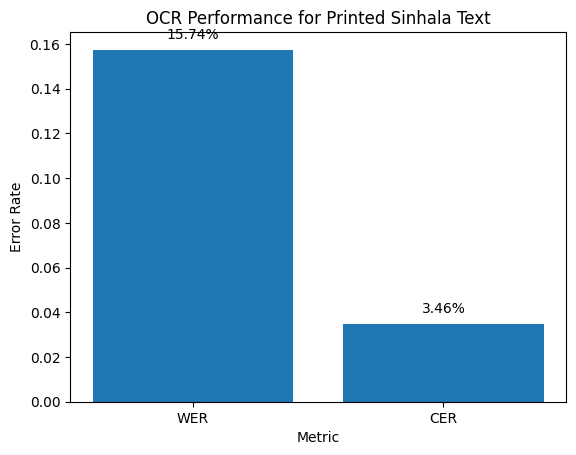

In [10]:
import matplotlib.pyplot as plt

# Calculate averages
avg_wer = total_wer / count
avg_cer = total_cer / count

labels = ['WER', 'CER']
values = [avg_wer, avg_cer]

plt.figure()
plt.bar(labels, values)
plt.title("OCR Performance for Printed Sinhala Text")
plt.ylabel("Error Rate")
plt.xlabel("Metric")

# Show values on top
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v*100:.2f}%", ha='center')

plt.show()

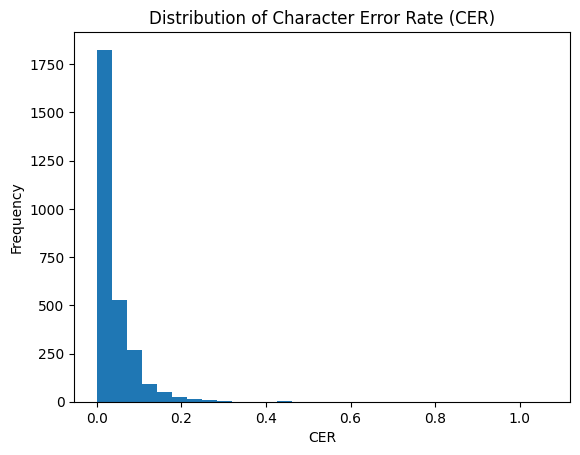

In [11]:
import pandas as pd

results_df = pd.DataFrame(results)

plt.figure()
plt.hist(results_df['cer'], bins=30)
plt.title("Distribution of Character Error Rate (CER)")
plt.xlabel("CER")
plt.ylabel("Frequency")
plt.show()